# 01 - Raw Movie Loading and Motion Correction

This notebook loads the raw calcium movie, performs bad-frame replacement, applies motion correction, and generates QC figures suitable for a methods supplement: raw-frame statistics, corrected-frame projections, before/after comparisons, and Suite2p registration diagnostics.

In [10]:
%matplotlib inline
import os, sys
from pathlib import Path

# Locate the repository root from the current notebook working directory.
def find_repo_root(start):
    start = Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "Airscope_ca").is_dir() and (path / "configs").is_dir():
            return path
    raise RuntimeError(f"Could not find repo root from {start}")

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(REPO_ROOT / "notebooks") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "notebooks"))

DATA_PATH = "/mnt/nas02/LAR/pico/ca_pipeline/demo_data/frames"
OUT_PATH = DATA_PATH.replace("frames", "Analysis")
print(f"REPO_ROOT : {REPO_ROOT}")
print(f"DATA_PATH : {DATA_PATH}")
print(f"OUT_PATH  : {OUT_PATH}")


REPO_ROOT : /data/home/angran/BBNC/code/PICO_ca_processing_release
DATA_PATH : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/frames
OUT_PATH  : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis


In [11]:
# Compose a reproducible Hydra config for this notebook run.
from hydra import initialize_config_dir, compose
from hydra.core.global_hydra import GlobalHydra
from omegaconf import OmegaConf

GlobalHydra.instance().clear()
with initialize_config_dir(config_dir=str(REPO_ROOT / "configs"), version_base=None):
    cfg = compose(
        config_name="config",
        overrides=[
            f"data_path={DATA_PATH}",
            f"out_path={OUT_PATH}",
            "motion=suite2p",
            "rmbg=ddp",
        ],
    )

print(OmegaConf.to_yaml(cfg))

motion:
  fr: 10
  mc_chunk_size: 1000
  zarr_chunk_size: 1000
  method: suite2p
  device: cuda
  suite2p:
    align_by_chan2: false
    nimg_init: 400
    maxregshift: 0.1
    do_bidiphase: false
    bidiphase: 0.0
    batch_size: 100
    nonrigid: true
    maxregshiftNR: 5
    block_size:
    - 128
    - 128
    smooth_sigma_time: 0
    smooth_sigma: 1.15
    spatial_taper: 3.45
    th_badframes: 1.0
    norm_frames: true
    snr_thresh: 1.2
    subpixel: 10
    two_step_registration: false
    reg_tif: false
    reg_tif_chan2: false
preprocessing:
  crop_parameter:
  - 153
  - 303
  - 1000
  - 1000
  intensity_corr_flag: false
  bad_frame_detect_flag: false
  preprocess_workers: 64
  preprocess_chunk_size: 512
  zarr_chunk_size: 500
rmbg:
  up_sample: 2
  rmbg_chunk_size: 1000
  zarr_chunk_size: 500
  rmbg_gsize: 6
  batch_size: 8
  print_interval: 20
  use_amp: true
  copy_interval: 4
  num_process_per_gpu: 2
  ckpt_pth: ckpt/background_rejection_ckpt_resize_2.pth
  device: cuda
  

In [12]:
# Imports used by this notebook only.
import os
import logging
from pathlib import Path

from Airscope_ca.process_script import build_paths, setup_logger
from Airscope_ca.pipeline import get_frame_count, load_raw_movie, correct_motion
from Airscope_ca.utils.io_videos import open_zarr_array
from airscope_notebook_tools import (
    set_publication_style,
    sample_indices,
    plot_frame_montage,
    plot_projection_panel,
    plot_before_after_frames,
    plot_difference_panel,
    display_existing_image,
    list_stage_outputs,
)

set_publication_style()
os.makedirs(OUT_PATH, exist_ok=True)
paths = build_paths(cfg)
logger = setup_logger(OUT_PATH)
logger.addHandler(logging.StreamHandler())

frame_count = get_frame_count(cfg)
print(f"Frame count: {frame_count}")
print(f"MC zarr    : {paths.mc_zarr_path}")
print(f"Pre zarr   : {paths.preprocess_zarr_path}")
print(f"RMBG zarr  : {paths.rmbg_zarr_path}")
print(f"Seg out    : {paths.seg_out}")


     5200885 [process_script.py:        setup_logger():87] [2822039] Logging INFO and above from root logger to /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/log_file.log


4000
Frame count: 4000
MC zarr    : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/mc/motion_corrected.zarr
Pre zarr   : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/preprocess/video_preprocessed.zarr
RMBG zarr  : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/rmbg/rmbg.zarr
Seg out    : /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/seg_results_thresh_pmap_1


## 1. Load Raw Movie and Inspect Acquisition Quality

=======>bad frame detection<=======

     5200983 [stage_read.py:      load_raw_movie():67] [2822039] =======>bad frame detection<=======

Reading raw JPG frames with 16 workers and cv2.IMREAD_GRAYSCALE
     5200985 [stage_read.py:      load_raw_movie():71] [2822039] Reading raw JPG frames with 16 workers and cv2.IMREAD_GRAYSCALE


4000


100%|██████████| 4000/4000 [00:00<00:00, 3041003.44it/s]


[]


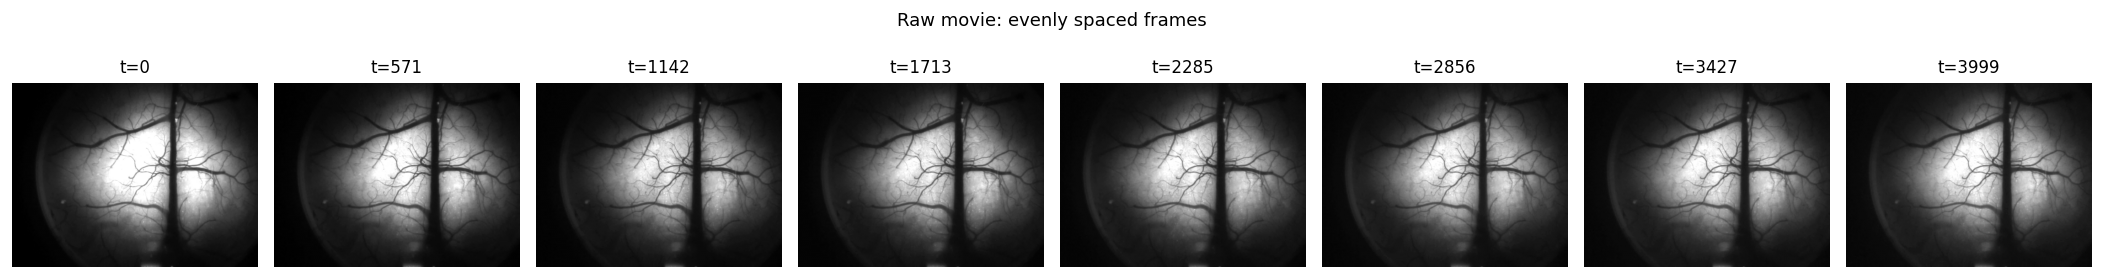

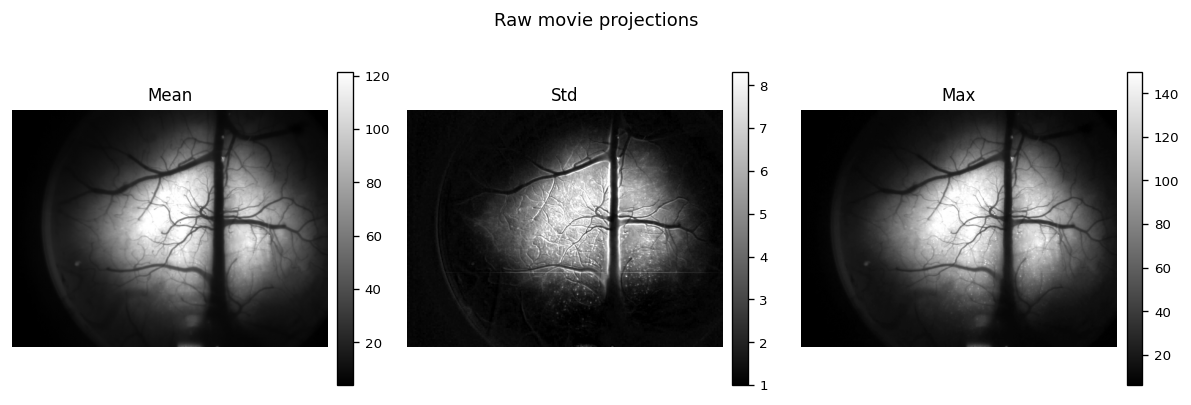

In [13]:
# Load raw frames, apply bad-frame replacement, then inspect representative frames.
video = load_raw_movie(cfg, paths, logger)
_ = plot_frame_montage(video, n=8, title="Raw movie: evenly spaced frames")
_ = plot_projection_panel(video, title="Raw movie projections", n_samples=96)


## 2. Run Motion Correction

In [14]:
# Run the configured registration backend and persist the corrected movie to Zarr.
print(f"motion method : {cfg.motion.method}")
print(f"device        : {cfg.motion.device}")
print(f"chunk size    : {cfg.motion.mc_chunk_size}")

mc_video = correct_motion(cfg, video, paths, logger)
print(f"Motion correction complete: {paths.mc_zarr_path}")

=======>motion correction<=======

     5256620 [stage_motion.py:      correct_motion():52] [2822039] =======>motion correction<=======



motion method : suite2p
device        : cuda
chunk size    : 1000


  0%|          | 0/4 [00:00<?, ?it/s]MC chunk 0: shape=(1000, 1200, 1600)
     5258270 [stage_motion.py:_correct_motion_suite2p():182] [2822039] MC chunk 0: shape=(1000, 1200, 1600)
     5258271 [register.py:registration_wrapper():855] [2822039] registering 1 channels
     5265639 [register.py:registration_wrapper():882] [2822039] Reference frame, 7.20 sec.
     5266412 [register.py:     register_frames():563] [2822039] Registering 1000 frames in 10 batches
     5266413 [logging_utils.py:               flush():23] [2822039] 
     5266414 [logging_utils.py:               flush():23] [2822039] 0%|          | 0/10 [00:00<?, ?it/s]
     5266414 [logging_utils.py:               flush():23] [2822039] 
     5272685 [logging_utils.py:               flush():23] [2822039] 100%|##########| 10/10 [00:06<00:00,  1.59it/s]
 25%|██▌       | 1/4 [00:16<00:48, 16.05s/it]MC chunk 1: shape=(1000, 1200, 1600)
     5274511 [stage_motion.py:_correct_motion_suite2p():182] [2822039] MC chunk 1: shape=(1000, 1

Motion correction complete: /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/mc/motion_corrected.zarr


## 3. Corrected Movie QC

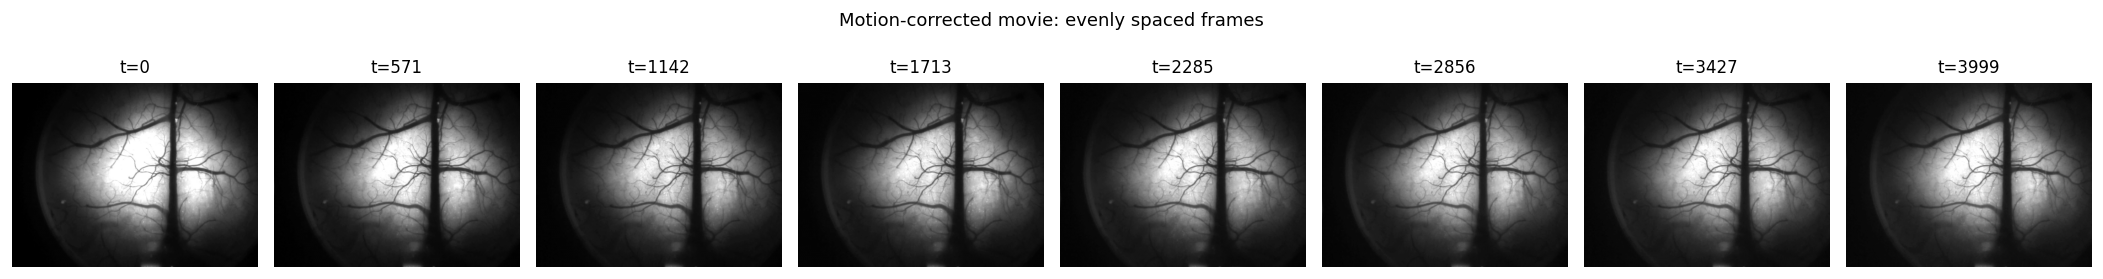

In [15]:
# Reopen the saved Zarr output to verify exactly what downstream stages will read.
mc_arr = open_zarr_array(paths.mc_zarr_path, mode="r")
_ = plot_frame_montage(mc_arr, n=8, title="Motion-corrected movie: evenly spaced frames")

## 4. Raw vs Corrected Frame Comparisons

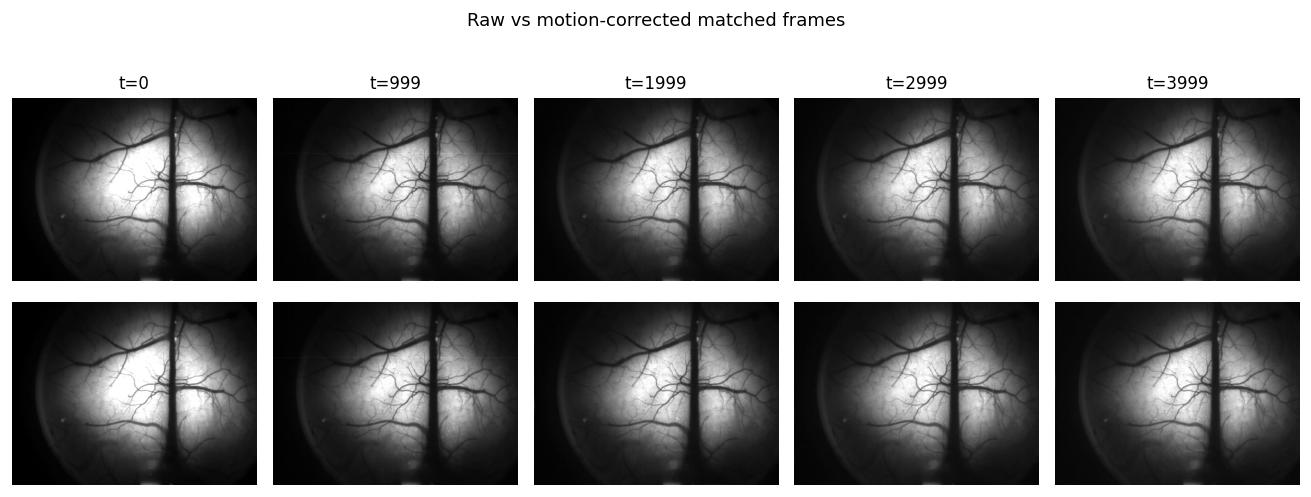

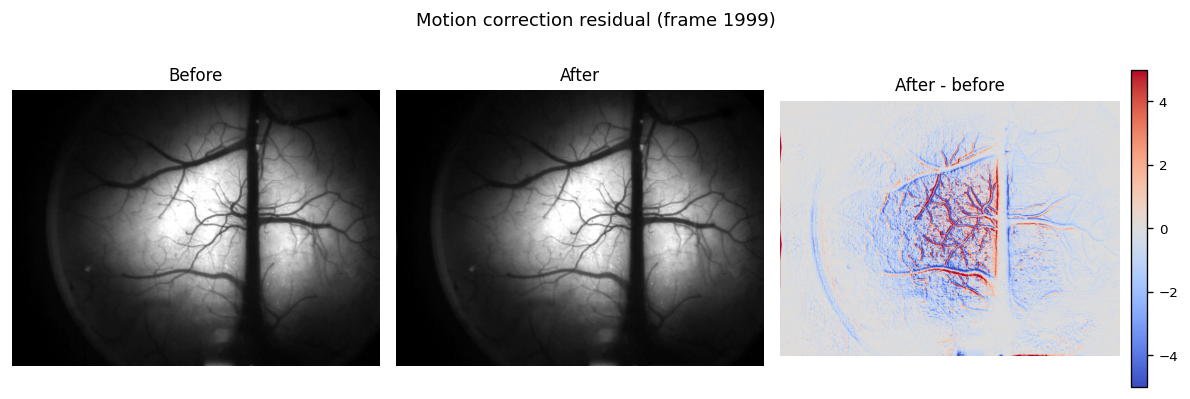

In [16]:
# Compare matched frames before and after registration to expose residual motion/artifacts.
compare_indices = sample_indices(min(len(video), mc_arr.shape[0]), n=5)
_ = plot_before_after_frames(video, mc_arr, indices=compare_indices, title="Raw vs motion-corrected matched frames")
_ = plot_difference_panel(video, mc_arr, index=int(compare_indices[len(compare_indices)//2]), title="Motion correction residual")

## 5. Registration Diagnostics Written by Suite2p

Suite2p rigid shift traces


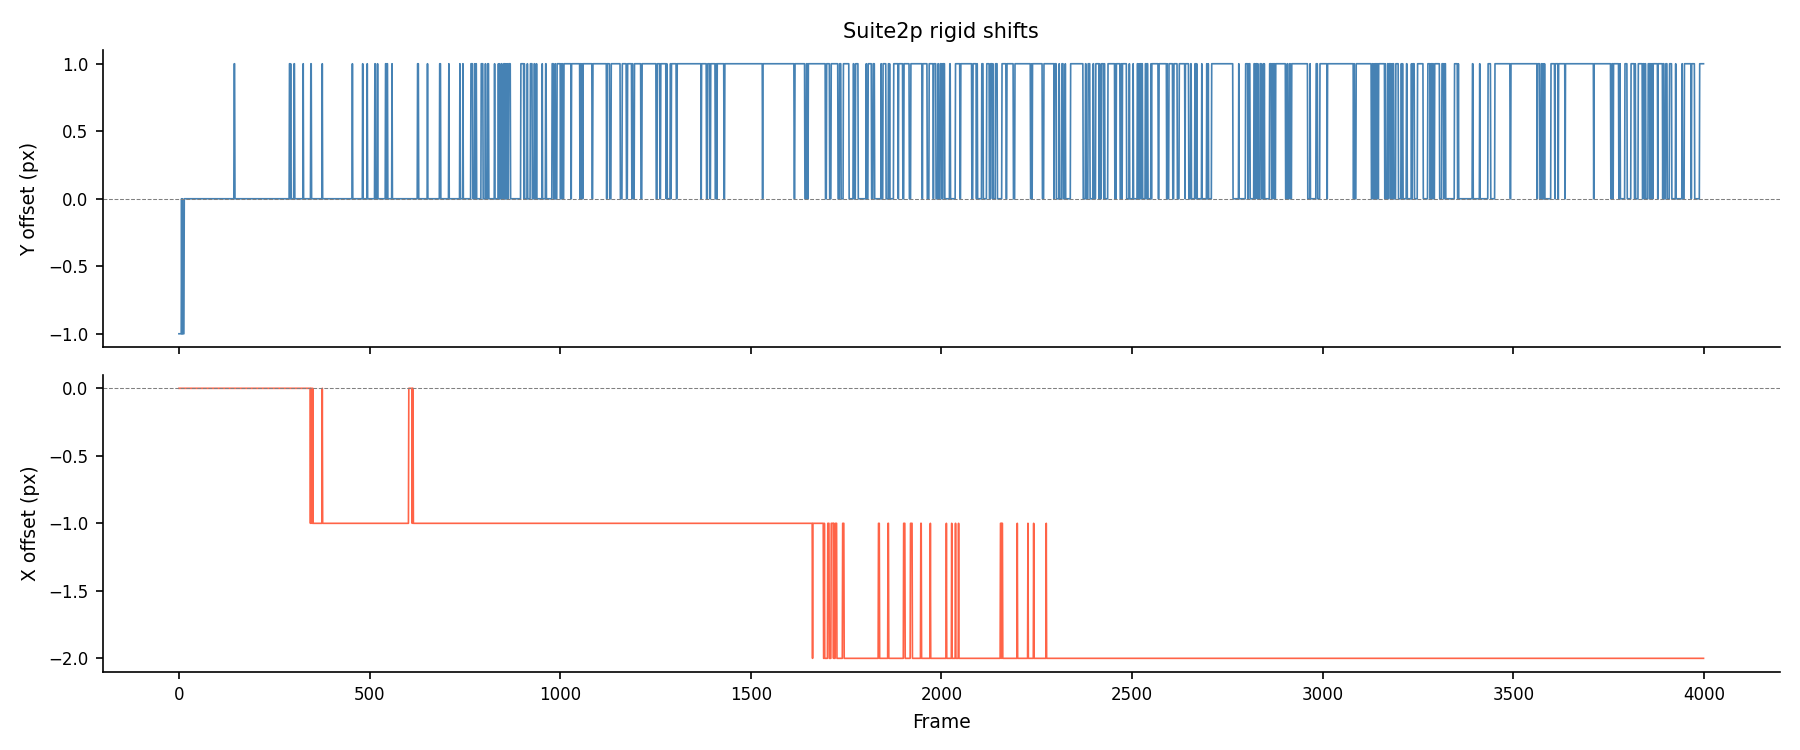

Suite2p reference image


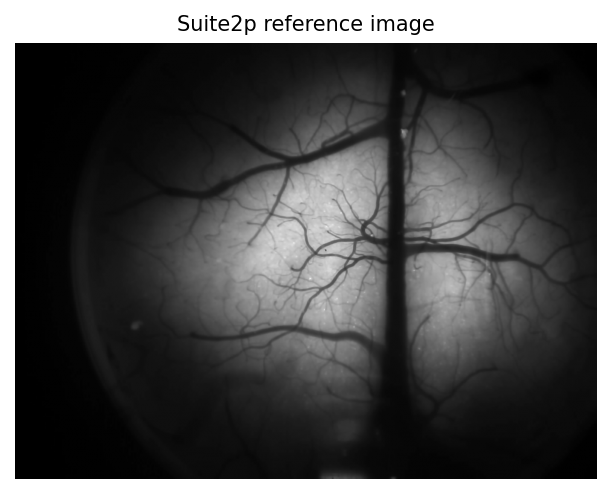

Output directory: /mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/mc
suite2p_refImg.npy
suite2p_refImg.png
suite2p_shifts.png


[PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/mc/suite2p_refImg.npy'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/mc/suite2p_refImg.png'),
 PosixPath('/mnt/nas02/LAR/pico/ca_pipeline/demo_data/Analysis/mc/suite2p_shifts.png')]

In [17]:
# Show diagnostic images written by the Suite2p registration wrapper.
display_existing_image(Path(paths.mc_out) / "suite2p_shifts.png", title="Suite2p rigid shift traces")
display_existing_image(Path(paths.mc_out) / "suite2p_refImg.png", title="Suite2p reference image")
list_stage_outputs(paths.mc_out, patterns=("*.png", "*.npy", "*.zarr"), max_items=40)